# California housing → bracket-contract prices

Take a regression dataset, predict a **distribution** over house prices,
then price a ladder of binary contracts ("will this house sell above
$X?") against the forecast distribution.

1. Fit three forecasters under one `WalkForward`: `Empirical`
   (baseline), `Ridge + GlobalResidual`, `QuantileReg`.
2. Score them on distribution-level (CRPS, PIT) and contract-level
   (Brier, log-loss) metrics.
3. Show *what those numbers actually mean* with diagnostic plots that
   each carry their own conclusion.
4. Run a wider **leaderboard** and rank everything.

In [1]:
import sys
import warnings
from pathlib import Path

# Make the paired _src/ helpers importable when executing the .ipynb.
sys.path.insert(0, str(Path.cwd() / "_src"))

import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import RidgeCV

warnings.filterwarnings(
    "ignore", message="X does not have valid feature names.*",
    category=UserWarning,
)

import matplotlib.pyplot as plt

# Shared style (rcParams + palette + plot helpers).
from _style import (
    cdf_overlay_for_examples,
    color_for,
    leaderboard_bar,
    predicted_vs_realized_grid,
    reliability_with_histogram,
)
from bracketlearn.baselines import EmpiricalDistribution
from bracketlearn.compose import WalkForward
from bracketlearn.lift import GlobalResidual
from bracketlearn.pipeline import Pipeline
from bracketlearn.score import pit, to_point
from bracketlearn.trainers import QuantileReg, SklearnPoint
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Data

California housing — sklearn-bundled, 20 640 rows, target = median house
value in $100k units. We subsample to 4 000 rows for notebook speed.

In [2]:
data = fetch_california_housing()
X = np.asarray(data.data, dtype=float)
y = np.asarray(data.target, dtype=float)
rng = np.random.default_rng(0)
keep = rng.choice(X.shape[0], size=4000, replace=False)
X, y = X[keep], y[keep]
ids = np.arange(X.shape[0])
ts = ids.astype(float)
print(f"X shape: {X.shape}   y range: ${y.min()*100:.0f}k–${y.max()*100:.0f}k")

X shape: (4000, 8)   y range: $18k–$500k


## Bracket ladder

8 buckets covering the realistic price range. Each forecast gets priced
against this ladder as a binary contract per bucket.

In [3]:
edges = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0])
print(f"{len(edges)-1} brackets covering ${edges[0]*100:.0f}k–${edges[-1]*100:.0f}k")

8 brackets covering $50k–$500k


## Fit the headline pipeline

In [4]:
model = [
    Pipeline([EmpiricalDistribution()], name="emp"),
    Pipeline([SklearnPoint(RidgeCV()), GlobalResidual()], name="ridge"),
    Pipeline([QuantileReg(n_estimators=200, learning_rate=0.05, random_seed=0)], name="qreg"),
]
wf = WalkForward(
    cv="kfold", n_folds=5, shuffle=True, random_state=0, refit_on_full=True,
)
result = wf.fit_predict(model, X, y, ids=ids, timestamps=ts)
print(result.to_table(y, metrics=["crps", "log_score", "pit"]))

stage              n_oof          crps     log_score      pit_mean       pit_std
--------------------------------------------------------------------------------
emp                 4000        0.6120        1.3754        0.4979        0.2925
ridge               4000        0.4048        2.5319        0.4769        0.2658
qreg                4000        0.2514       -0.4010        0.4820        0.3156


## Headline diagnostic — predicted vs realized

This is the "OK but does the model actually work?" plot, modelled on
sklearn's
[`plot_stack_predictors`](https://scikit-learn.org/stable/auto_examples/ensemble/plot_stack_predictors.html)
example. One scatter panel per model; each panel has:

- dots for `(realized, predicted-mean)` per row
- a black dashed diagonal — perfect prediction
- the model's CRPS / RMSE / MAE annotated inside the panel

Points clinging to the diagonal = good. Wide vertical scatter at one
*x*-value = the model isn't separating that range. Drift away from the
diagonal = bias.

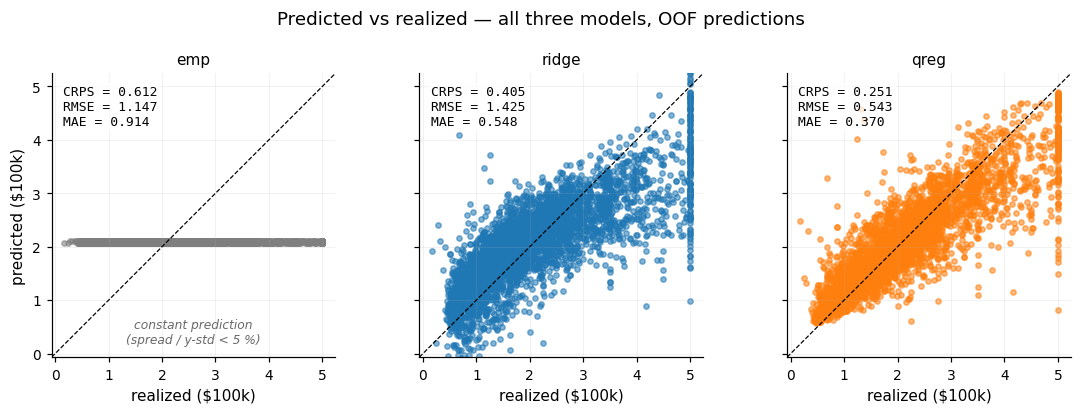

In [5]:
crps_scores = result.score(y, metrics=["crps"])
panels = []
for name in ["emp", "ridge", "qreg"]:
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    mu = to_point(dist, how="mean")
    rmse = float(np.sqrt(mean_squared_error(y_oof, mu)))
    mae = float(mean_absolute_error(y_oof, mu))
    crps = float(crps_scores[name]["crps"])
    panels.append((name, mu, y_oof,
                   {"CRPS": crps, "RMSE": rmse, "MAE": mae}))

fig = predicted_vs_realized_grid(
    panels, ncols=3, units="$100k",
    title="Predicted vs realized — all three models, OOF predictions",
)
plt.show()

**Read it:** `emp` predicts the same number for every row (the marginal
mean), so all dots collapse onto one horizontal stripe — instructive
floor. `ridge` shows clear linear structure but underpredicts at the
top end. `qreg` tracks the diagonal across the full range.

## PIT histograms — is each forecast *calibrated*?

The Probability Integral Transform of the realized y under the forecast
CDF should be **uniform on [0, 1]** if the model is well-calibrated.
- **U-shape** = overconfident (forecasts too narrow).
- **inverted-U** = underconfident.
- **left/right peak** = biased.

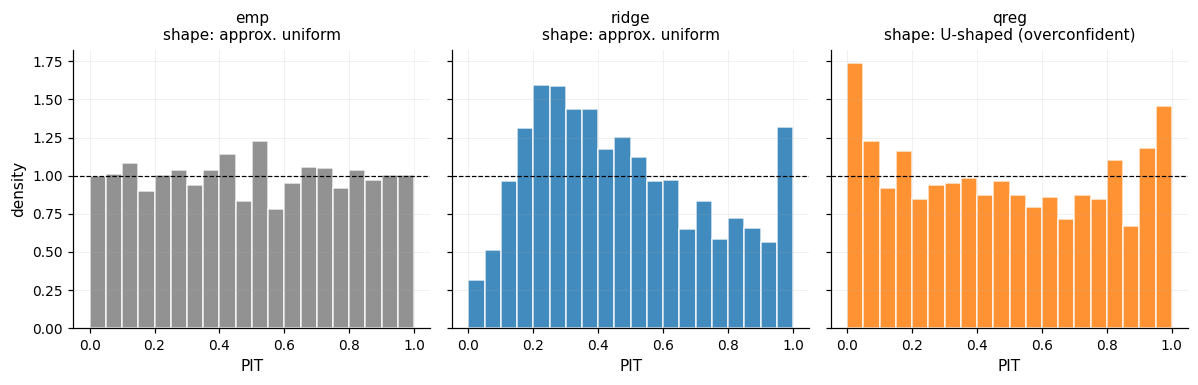

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, name in zip(axes, ["emp", "ridge", "qreg"], strict=True):
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    pit_vals = pit(dist, y_oof)
    ax.hist(pit_vals, bins=20, color=color_for(name),
            edgecolor="white", density=True, alpha=0.85)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
    # Quick shape diagnosis.
    p25, p50, p75 = np.percentile(pit_vals, [25, 50, 75])
    diagnosis = (
        "U-shaped (overconfident)" if (pit_vals < 0.1).mean() + (pit_vals > 0.9).mean() > 0.25
        else "inverted-U (underconfident)" if (pit_vals > 0.4).mean() < 0.15
        else "approx. uniform"
    )
    ax.set_title(f"{name}\nshape: {diagnosis}", fontsize=10)
    ax.set_xlabel("PIT")
axes[0].set_ylabel("density")
fig.tight_layout()
plt.show()

## Quantile fan vs the feature most correlated with price

For QuantileReg, plot the 10/50/90 % predictive band as a function of
the feature most correlated with the target — here `MedInc` (median
income, by far the dominant signal in California housing). A
well-calibrated forecast has ~80 % of realised dots inside the band.

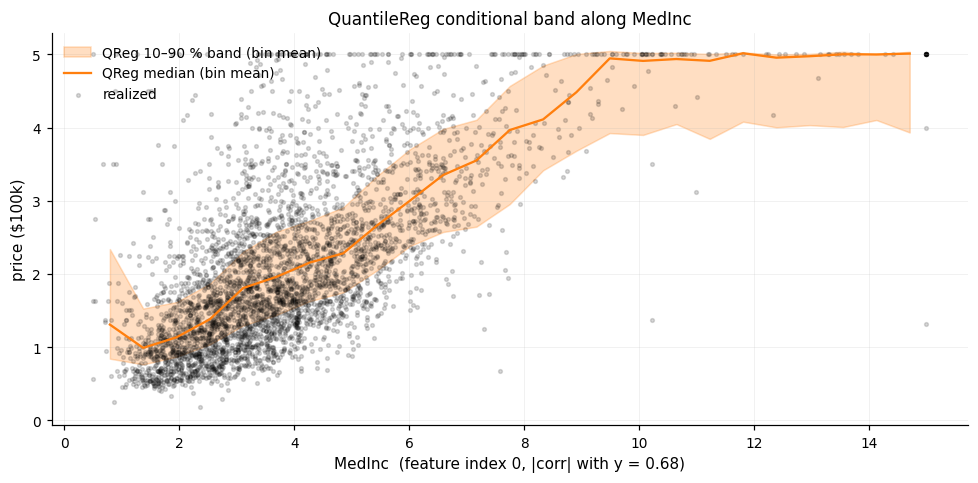

In [7]:
dist_qreg = result["qreg"]
y_oof = y[dist_qreg.ids.astype(int)]
# Feature with highest |corr| with y.
corrs = np.array([np.corrcoef(X[dist_qreg.ids.astype(int), j], y_oof)[0, 1]
                  for j in range(X.shape[1])])
feat_idx = int(np.argmax(np.abs(corrs)))
feat_name = data.feature_names[feat_idx]
x_feat = X[dist_qreg.ids.astype(int), feat_idx]

i_lo = np.argmin(np.abs(dist_qreg.taus - 0.1))
i_md = np.argmin(np.abs(dist_qreg.taus - 0.5))
i_hi = np.argmin(np.abs(dist_qreg.taus - 0.9))

# Bin x_feat into 25 buckets, take mean / quantile mean within each.
n_bins = 25
bins = np.linspace(x_feat.min(), x_feat.max(), n_bins + 1)
bin_idx = np.clip(np.searchsorted(bins, x_feat) - 1, 0, n_bins - 1)
band_lo = np.array([dist_qreg.qvals[bin_idx == b, i_lo].mean() if (bin_idx == b).any() else np.nan
                    for b in range(n_bins)])
band_md = np.array([dist_qreg.qvals[bin_idx == b, i_md].mean() if (bin_idx == b).any() else np.nan
                    for b in range(n_bins)])
band_hi = np.array([dist_qreg.qvals[bin_idx == b, i_hi].mean() if (bin_idx == b).any() else np.nan
                    for b in range(n_bins)])
bin_centres = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(bin_centres, band_lo, band_hi,
                alpha=0.25, color=color_for("qreg"),
                label="QReg 10–90 % band (bin mean)")
ax.plot(bin_centres, band_md, color=color_for("qreg"), lw=1.5,
        label="QReg median (bin mean)")
ax.scatter(x_feat, y_oof, s=6, color="black", alpha=0.15, label="realized")
ax.set_xlabel(f"{feat_name}  (feature index {feat_idx}, "
              f"|corr| with y = {abs(corrs[feat_idx]):.2f})")
ax.set_ylabel("price ($100k)")
ax.set_title(f"QuantileReg conditional band along {feat_name}")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Per-house CDFs (replaces grouped bars)

Pick three held-out houses with **distinct** realised prices (one
cheap, one median, one expensive). For each house, overlay each
model's predicted CDF and mark the realised price. A model whose CDF
crosses 0.5 near the realised value got the *centre* right; a model
with a steeper CDF was more confident.

example house indices: [3081, 1776, 1959]  realised: $84k, $181k, $379k


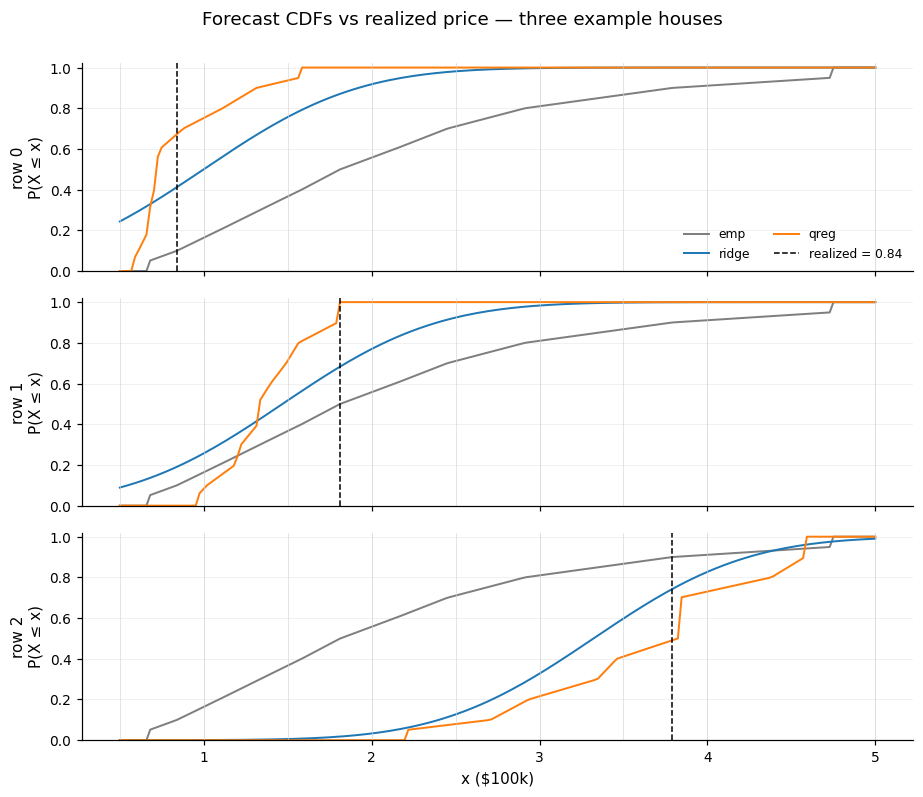

In [8]:
# Pick three rows with realised prices at the 10 %, 50 %, 90 %
# quantiles of y so they're visually distinct.
q_targets = np.quantile(y, [0.1, 0.5, 0.9])
example_ids = [int(np.argmin(np.abs(y - q))) for q in q_targets]
print(f"example house indices: {example_ids}  realised: "
      + ", ".join(f"${y[i]*100:.0f}k" for i in example_ids))

pred = wf.predict(
    X[example_ids],
    ids=np.arange(len(example_ids)),
    timestamps=np.arange(len(example_ids), dtype=float),
)
fig = cdf_overlay_for_examples(
    {"emp": pred["emp"], "ridge": pred["ridge"], "qreg": pred["qreg"]},
    row_indices=list(range(len(example_ids))),
    y_realized=y[example_ids],
    edges=edges,
    units="$100k",
    title="Forecast CDFs vs realized price — three example houses",
)
plt.show()

## Reliability — bracket probabilities calibrated?

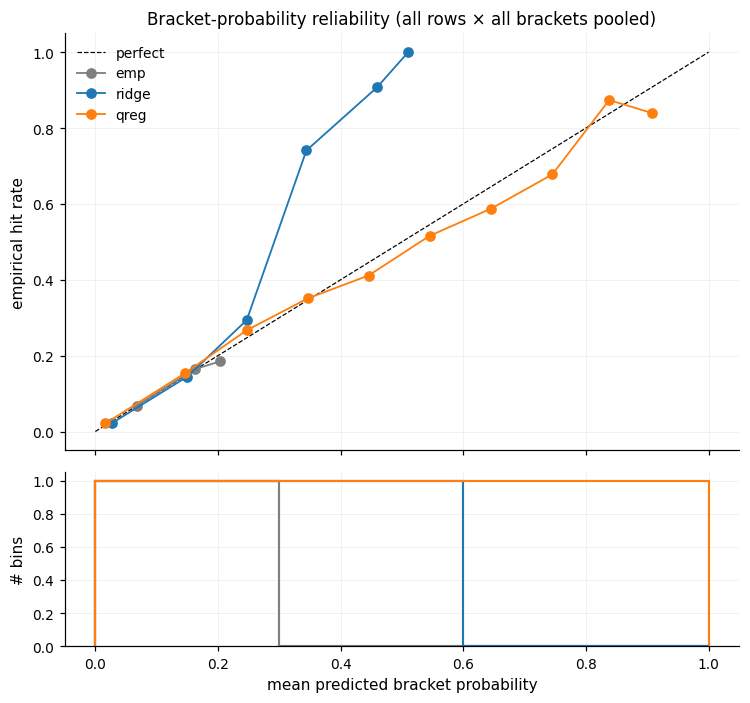

In [9]:
def _reliability(dist, edges, y_oof, n_bins=10):
    cdf_hi = dist.cdf(edges[1:])
    cdf_lo = dist.cdf(edges[:-1])
    probs = np.clip(cdf_hi - cdf_lo, 0, 1)
    bin_idx = np.searchsorted(edges, y_oof, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, probs.shape[1] - 1)
    realized = np.zeros_like(probs)
    realized[np.arange(probs.shape[0]), bin_idx] = 1.0
    p_flat = probs.reshape(-1)
    r_flat = realized.reshape(-1)
    edges_p = np.linspace(0, 1, n_bins + 1)
    means, hits = [], []
    for i in range(n_bins):
        mask = (p_flat >= edges_p[i]) & (p_flat < edges_p[i + 1] + (i == n_bins - 1))
        if mask.sum() < 5:
            continue
        means.append(p_flat[mask].mean())
        hits.append(r_flat[mask].mean())
    return np.array(means), np.array(hits)


series = []
for name in ["emp", "ridge", "qreg"]:
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    mp, hr = _reliability(dist, edges, y_oof)
    series.append((name, mp, hr))
fig = reliability_with_histogram(
    series, title="Bracket-probability reliability (all rows × all brackets pooled)",
)
plt.show()

## Wider leaderboard

Same five-fold CV, ranked by CRPS. Skill score (CRPSS) is reported
against the `Empirical` floor.

rank model                   CRPS  log_score    RMSE    CRPSS
--------------------------------------------------------------
1    QuantileReg           0.2514    -0.4010   0.543   +0.589
2    QuantileForest        0.2725    -0.3698   0.580   +0.555
3    NGBoostNormal         0.3437     0.9247   0.646   +0.438
4    Ridge+GR              0.4048     2.5319   1.425   +0.339
5    Empirical             0.6120     1.3754   1.147   +0.000


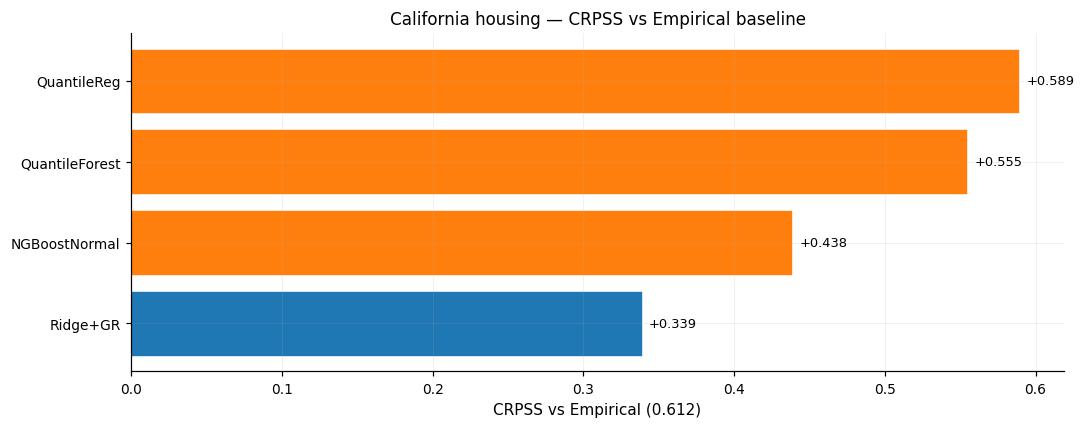

In [10]:
from bracketlearn.trainers import NGBoostNormal, QuantileForest


def _score_one(stage_name, forecaster):
    model = forecaster if isinstance(forecaster, Pipeline) else Pipeline([forecaster], name=stage_name)
    key = model.name
    r = WalkForward(
        cv="kfold", n_folds=5, shuffle=True, random_state=0, refit_on_full=False,
    ).fit_predict(model, X, y, ids=ids, timestamps=ts)
    metrics = r.score(y, metrics=["crps", "log_score"])[key]
    dist = r[key]
    y_oof = y[dist.ids.astype(int)]
    mu = to_point(dist, how="mean")
    return {
        "crps": float(metrics["crps"]),
        "log_score": float(metrics["log_score"]),
        "rmse": float(np.sqrt(mean_squared_error(y_oof, mu))),
        "mae":  float(mean_absolute_error(y_oof, mu)),
    }


leaderboard = {
    "Empirical":     _score_one("emp", EmpiricalDistribution()),
    "Ridge+GR":      _score_one("ridge", Pipeline(
        [SklearnPoint(RidgeCV()), GlobalResidual()], name="ridge",
    )),
    "NGBoostNormal": _score_one("ngb", NGBoostNormal(
        n_estimators=200, random_seed=0,
    )),
    "QuantileReg":   _score_one("qreg", QuantileReg(
        n_estimators=200, learning_rate=0.05, random_seed=0,
    )),
    "QuantileForest": _score_one("qf", QuantileForest(
        n_estimators=200, random_seed=0,
    )),
}

base_crps = leaderboard["Empirical"]["crps"]
rows = sorted(leaderboard.items(), key=lambda kv: kv[1]["crps"])
print(f"{'rank':<5}{'model':<18}{'CRPS':>10}{'log_score':>11}{'RMSE':>8}{'CRPSS':>9}")
print("-" * 62)
for i, (n, m) in enumerate(rows, 1):
    print(f"{i:<5}{n:<18}{m['crps']:>10.4f}{m['log_score']:>11.4f}"
          f"{m['rmse']:>8.3f}{1 - m['crps']/base_crps:>+9.3f}")

fig = leaderboard_bar(
    [(n, m["crps"]) for n, m in rows],
    baseline_name="Empirical", baseline_value=base_crps,
    skill_label="CRPSS",
    title="California housing — CRPSS vs Empirical baseline",
)
plt.show()

## Does it beat sklearn on the point-prediction metric?

Collapse each distribution to its mean and compare RMSE / MAE against
plain regressors. Same headline scatter grid, but now including two
classical baselines.

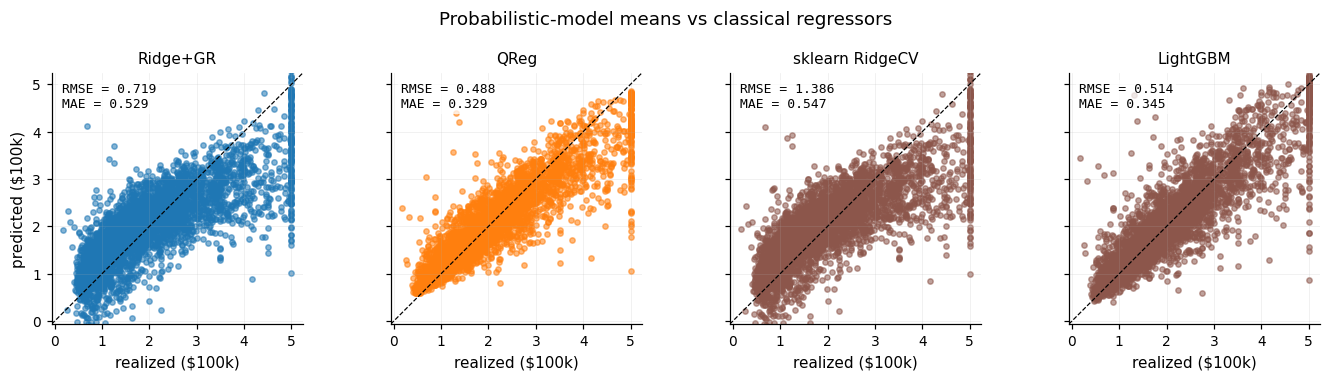

In [11]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold


def _sklearn_oof(model_factory):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    preds = np.empty_like(y)
    for tr, te in kf.split(X):
        m = model_factory()
        m.fit(X[tr], y[tr])
        preds[te] = m.predict(X[te])
    return preds


ridge_pred = _sklearn_oof(lambda: RidgeCV())
lgb_pred = _sklearn_oof(lambda: LGBMRegressor(
    n_estimators=200, learning_rate=0.05, verbose=-1, random_state=0,
))

# Three probabilistic models (best of family) + two classical regressors.
point_panels = []
for name, mu, y_ref in [
    ("Ridge+GR", to_point(wf.predict(
        X, ids=ids, timestamps=ts)["ridge"], how="mean"), y),
    ("QReg", to_point(wf.predict(
        X, ids=ids, timestamps=ts)["qreg"], how="mean"), y),
    ("sklearn RidgeCV", ridge_pred, y),
    ("LightGBM",        lgb_pred,    y),
]:
    rmse = float(np.sqrt(mean_squared_error(y_ref, mu)))
    mae = float(mean_absolute_error(y_ref, mu))
    point_panels.append((name, mu, y_ref, {"RMSE": rmse, "MAE": mae}))

fig = predicted_vs_realized_grid(
    point_panels, ncols=4, units="$100k",
    figsize_per_panel=(3.2, 3.2),
    title="Probabilistic-model means vs classical regressors",
)
plt.show()

The probabilistic models give you everything `LGBMRegressor` gives you
(point prediction, comparable RMSE) **plus** a full forecast
distribution — which is the only thing you can use to price the
bracket contracts in this notebook.